# Low Review Score Prediction

## Objective

Develop a classification workflow that estimates whether a delivered order will receive a low review score of 1 or 2. The model is evaluated using a chronological split and metrics appropriate for an imbalanced target.

The prediction point is defined as after delivery but before the customer submits a review. Therefore, order, payment, basket, customer-location, and completed-delivery information may be used, while review-derived fields other than the target are excluded to prevent leakage.

This notebook is an offline modeling demonstration. Its results should not be interpreted as a deployed customer-satisfaction system or as evidence of causation.

## 1. Data Loading

Load the cleaned order-item, product, and category-translation tables required to construct category-level customer baskets.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print(
    "Order records loaded:",
    f"{len(order_analytics):,}"
)

print(
    "Delivered orders:",
    f"{order_analytics['order_status'].eq('delivered').sum():,}"
)

print(
    "Analysis period:",
    order_analytics["order_purchase_timestamp"]
    .min()
    .date(),
    "to",
    order_analytics["order_purchase_timestamp"]
    .max()
    .date()
)

Order records loaded: 99,441
Delivered orders: 96,478
Analysis period: 2016-09-04 to 2018-10-17


## 2. Define the Modeling Population and Target

Retain delivered orders with a valid latest review score and define low satisfaction as a score of 1 or 2. Each order represents one modeling record.

In [3]:
modeling_orders = (
    order_analytics.loc[
        order_analytics["order_status"].eq(
            "delivered"
        )
        & order_analytics[
            "latest_review_score"
        ].between(1, 5)
    ]
    .copy()
    .sort_values(
        "order_purchase_timestamp"
    )
    .reset_index(drop=True)
)

modeling_orders["low_review_flag"] = (
    modeling_orders[
        "latest_review_score"
    ].le(2)
    .astype(int)
)

target_summary = (
    modeling_orders[
        "low_review_flag"
    ]
    .value_counts()
    .rename_axis("low_review_flag")
    .reset_index(name="orders")
)

target_summary["review_group"] = (
    target_summary["low_review_flag"]
    .map({
        0: "Review score 3–5",
        1: "Low review score 1–2"
    })
)

target_summary["order_share"] = (
    target_summary["orders"]
    / target_summary["orders"].sum()
)

target_summary = target_summary[
    [
        "review_group",
        "orders",
        "order_share"
    ]
]

duplicate_order_ids = modeling_orders[
    "order_id"
].duplicated().sum()

print(
    "Reviewed delivered orders:",
    f"{len(modeling_orders):,}"
)

print(
    "Low-review orders:",
    f"{modeling_orders['low_review_flag'].sum():,}"
)

print(
    "Low-review rate:",
    f"{modeling_orders['low_review_flag'].mean():.2%}"
)

print(
    "Duplicate order IDs:",
    duplicate_order_ids
)

display(
    target_summary.style.format({
        "orders": "{:,.0f}",
        "order_share": "{:.2%}"
    })
)

Reviewed delivered orders: 95,832
Low-review orders: 12,273
Low-review rate: 12.81%
Duplicate order IDs: 0


,review_group,orders,order_share
0,Review score 3–5,"83,559",87.19%
1,Low review score 1–2,"12,273",12.81%


***Observation:*** The modeling population contains 95,832 reviewed delivered orders with no duplicate order IDs. Low reviews account for 12.81% of records, confirming a meaningful class imbalance that makes accuracy alone an unsuitable evaluation metric.

## 3. Engineer Pre-Review Modeling Features

Create order, payment, basket, geography, purchase-timing, and completed-delivery features available before the review is submitted, while excluding all review-derived predictors.

In [4]:
modeling_orders["purchase_month"] = (
    modeling_orders[
        "order_purchase_timestamp"
    ].dt.month
)

modeling_orders["purchase_day_of_week"] = (
    modeling_orders[
        "order_purchase_timestamp"
    ].dt.dayofweek
)

modeling_orders["purchase_hour"] = (
    modeling_orders[
        "order_purchase_timestamp"
    ].dt.hour
)

modeling_orders["estimated_delivery_days"] = (
    (
        modeling_orders[
            "order_estimated_delivery_date"
        ]
        - modeling_orders[
            "order_purchase_timestamp"
        ]
    )
    .dt.total_seconds()
    .div(86_400)
)

modeling_orders["delivery_metric_available"] = (
    modeling_orders[
        "is_valid_for_delivery_analysis"
    ]
    .fillna(False)
    .astype(int)
)

modeling_orders["multi_item_order"] = (
    modeling_orders["item_count"]
    .fillna(0)
    .gt(1)
    .astype(int)
)

modeling_orders["multi_seller_order"] = (
    modeling_orders[
        "distinct_seller_count"
    ]
    .fillna(0)
    .gt(1)
    .astype(int)
)

numeric_features = [
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "item_count",
    "distinct_product_count",
    "distinct_seller_count",
    "product_value",
    "freight_value",
    "average_item_price",
    "item_total_value",
    "total_payment_value",
    "payment_method_count",
    "maximum_installments",
    "estimated_delivery_days",
    "delivery_days",
    "delivery_delay_days",
    "multi_item_order",
    "multi_seller_order",
    "delivery_metric_available"
]

categorical_features = [
    "customer_state",
    "primary_payment_type"
]

model_features = (
    numeric_features
    + categorical_features
)

target_column = "low_review_flag"

X = modeling_orders[
    model_features
].copy()

y = modeling_orders[
    target_column
].copy()

feature_audit = pd.DataFrame({
    "feature": model_features,
    "data_type": [
        str(X[column].dtype)
        for column in model_features
    ],
    "non_null_values": [
        X[column].notna().sum()
        for column in model_features
    ],
    "missing_values": [
        X[column].isna().sum()
        for column in model_features
    ],
    "unique_values": [
        X[column].nunique(
            dropna=True
        )
        for column in model_features
    ]
})

feature_audit["missing_rate"] = (
    feature_audit["missing_values"]
    / len(X)
)

review_derived_predictors = [
    column
    for column in model_features
    if "review" in column.lower()
]

display(
    feature_audit.style.format({
        "non_null_values": "{:,.0f}",
        "missing_values": "{:,.0f}",
        "missing_rate": "{:.2%}",
        "unique_values": "{:,.0f}"
    })
)

print(
    "Modeling features:",
    len(model_features)
)

print(
    "Review-derived predictors included:",
    len(review_derived_predictors)
)

print(
    "Features containing missing values:",
    f"{feature_audit['missing_values'].gt(0).sum():,}"
)

,feature,data_type,non_null_values,missing_values,unique_values,missing_rate
0,purchase_month,int32,"95,832",0,12,0.00%
1,purchase_day_of_week,int32,"95,832",0,7,0.00%
2,purchase_hour,int32,"95,832",0,24,0.00%
3,item_count,int64,"95,832",0,17,0.00%
4,distinct_product_count,int64,"95,832",0,8,0.00%
5,distinct_seller_count,int64,"95,832",0,5,0.00%
6,product_value,float64,"95,832",0,"7,490",0.00%
7,freight_value,float64,"95,832",0,"7,685",0.00%
8,average_item_price,float64,"95,832",0,"6,950",0.00%
9,item_total_value,float64,"95,832",0,"28,739",0.00%


Modeling features: 21
Review-derived predictors included: 0
Features containing missing values: 5


***Observation:*** The model uses 21 predictors and includes no review-derived inputs, preserving the defined pre-review prediction point. Missingness is limited to five features and is very small—primarily 196 orders without valid delivery metrics—so it can be handled within the modeling pipeline without removing records.

## 4. Create a Chronological Train-Test Split

Train on orders purchased before April 2018 and reserve later orders for testing, ensuring that future transactions do not influence model development.

In [5]:
split_date = pd.Timestamp("2018-04-01")

train_mask = (
    modeling_orders[
        "order_purchase_timestamp"
    ] < split_date
)

test_mask = ~train_mask

X_train = X.loc[
    train_mask
].copy()

X_test = X.loc[
    test_mask
].copy()

y_train = y.loc[
    train_mask
].copy()

y_test = y.loc[
    test_mask
].copy()

train_dates = modeling_orders.loc[
    train_mask,
    "order_purchase_timestamp"
]

test_dates = modeling_orders.loc[
    test_mask,
    "order_purchase_timestamp"
]

split_summary = pd.DataFrame({
    "dataset": [
        "Training",
        "Test"
    ],
    "start_date": [
        train_dates.min(),
        test_dates.min()
    ],
    "end_date": [
        train_dates.max(),
        test_dates.max()
    ],
    "orders": [
        len(X_train),
        len(X_test)
    ],
    "low_review_orders": [
        y_train.sum(),
        y_test.sum()
    ],
    "low_review_rate": [
        y_train.mean(),
        y_test.mean()
    ]
})

chronological_split_valid = int(
    train_dates.max()
    < test_dates.min()
)

display(
    split_summary.style.format({
        "start_date": lambda value: (
            value.strftime("%Y-%m-%d")
        ),
        "end_date": lambda value: (
            value.strftime("%Y-%m-%d")
        ),
        "orders": "{:,.0f}",
        "low_review_orders": "{:,.0f}",
        "low_review_rate": "{:.2%}"
    })
)

print(
    "Split date:",
    split_date.date()
)

print(
    "Chronological split valid:",
    bool(chronological_split_valid)
)

print(
    "Training share:",
    f"{len(X_train) / len(X):.2%}"
)

,dataset,start_date,end_date,orders,low_review_orders,low_review_rate
0,Training,2016-09-15,2018-03-31,"63,832","8,951",14.02%
1,Test,2018-04-01,2018-08-29,"32,000","3,322",10.38%


Split date: 2018-04-01
Chronological split valid: True
Training share: 66.61%


***Observation:*** The chronological split assigns 63,832 earlier orders to training and 32,000 later orders to testing, with no overlap between their date ranges. The low-review rate declines from 14.02% to 10.38%, indicating temporal target drift that the evaluation must account for.

## 5. Establish a Majority-Class Baseline

Evaluate a no-skill classifier that predicts every test order as non-low-review, providing a minimum benchmark for recall, F1, PR-AUC, and balanced accuracy.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score
)

baseline_predictions = np.zeros(
    len(y_test),
    dtype=int
)

baseline_probabilities = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_results = pd.DataFrame({
    "model": [
        "Majority-class baseline"
    ],
    "accuracy": [
        accuracy_score(
            y_test,
            baseline_predictions
        )
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(
            y_test,
            baseline_predictions
        )
    ],
    "precision": [
        precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        )
    ],
    "recall": [
        recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        )
    ],
    "f1_score": [
        f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        )
    ],
    "pr_auc": [
        average_precision_score(
            y_test,
            baseline_probabilities
        )
    ],
    "roc_auc": [
        roc_auc_score(
            y_test,
            baseline_probabilities
        )
    ]
})

display(
    baseline_results.style.format({
        "accuracy": "{:.2%}",
        "balanced_accuracy": "{:.2%}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1_score": "{:.2%}",
        "pr_auc": "{:.2%}",
        "roc_auc": "{:.2%}"
    })
)

print(
    "Test low-review prevalence:",
    f"{y_test.mean():.2%}"
)

print(
    "Low reviews identified by baseline:",
    f"{baseline_predictions.sum():,}"
)

,model,accuracy,balanced_accuracy,precision,recall,f1_score,pr_auc,roc_auc
0,Majority-class baseline,89.62%,50.00%,0.00%,0.00%,0.00%,10.38%,50.00%


Test low-review prevalence: 10.38%
Low reviews identified by baseline: 0


***Observation:*** The majority-class baseline reaches 89.62% accuracy but identifies none of the 3,322 low-review orders, producing zero precision, recall, and F1. Its 10.38% PR-AUC and 50.00% ROC-AUC confirm that high raw accuracy is caused entirely by class imbalance rather than predictive ability.

## 6. Train Logistic Regression Models

Build leakage-safe preprocessing pipelines and compare standard logistic regression with a class-weighted version designed to give greater importance to low-review orders.

In [7]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

logistic_models = {
    "Logistic regression": LogisticRegression(
        max_iter=2_000,
        random_state=42
    ),
    "Class-weighted logistic regression":
        LogisticRegression(
            max_iter=2_000,
            class_weight="balanced",
            random_state=42
        )
}

trained_models = {}
classification_metric_records = []

for model_name, classifier in (
    logistic_models.items()
):
    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predicted_probabilities = (
        pipeline.predict_proba(
            X_test
        )[:, 1]
    )

    predicted_classes = (
        predicted_probabilities >= 0.50
    ).astype(int)

    trained_models[model_name] = pipeline

    classification_metric_records.append({
        "model": model_name,
        "decision_threshold": 0.50,
        "accuracy": accuracy_score(
            y_test,
            predicted_classes
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                predicted_classes
            ),
        "precision": precision_score(
            y_test,
            predicted_classes,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predicted_classes,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            predicted_classes,
            zero_division=0
        ),
        "pr_auc": average_precision_score(
            y_test,
            predicted_probabilities
        ),
        "roc_auc": roc_auc_score(
            y_test,
            predicted_probabilities
        ),
        "predicted_low_reviews":
            predicted_classes.sum()
    })

logistic_model_results = pd.DataFrame(
    classification_metric_records
)

model_comparison = pd.concat(
    [
        baseline_results.assign(
            decision_threshold=0.50,
            predicted_low_reviews=(
                baseline_predictions.sum()
            )
        ),
        logistic_model_results
    ],
    ignore_index=True
)

model_comparison = model_comparison[
    [
        "model",
        "decision_threshold",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score",
        "pr_auc",
        "roc_auc",
        "predicted_low_reviews"
    ]
]

display(
    model_comparison.style.format({
        "decision_threshold": "{:.2f}",
        "accuracy": "{:.2%}",
        "balanced_accuracy": "{:.2%}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1_score": "{:.2%}",
        "pr_auc": "{:.2%}",
        "roc_auc": "{:.2%}",
        "predicted_low_reviews": "{:,.0f}"
    })
)

,model,decision_threshold,accuracy,balanced_accuracy,precision,recall,f1_score,pr_auc,roc_auc,predicted_low_reviews
0,Majority-class baseline,0.50,89.62%,50.00%,0.00%,0.00%,0.00%,10.38%,50.00%,0
1,Logistic regression,0.50,89.96%,53.80%,62.73%,8.16%,14.44%,30.08%,69.66%,432
2,Class-weighted logistic regression,0.50,82.31%,64.94%,27.49%,43.02%,33.54%,29.84%,70.09%,"5,198"


***Observation:*** Standard logistic regression preserves high accuracy but detects only 8.16% of low-review orders. Class weighting increases recall to 43.02% and produces the strongest F1 score and balanced accuracy, although precision falls to 27.49%; both models achieve PR-AUC near 30%, substantially above the 10.38% no-skill baseline.

## 7. Select a Decision Threshold Using Validation Data

Choose the classification threshold on a separate chronological validation period, then evaluate that fixed threshold on the untouched test period to avoid test-set optimization.

In [8]:
from sklearn.base import clone
from sklearn.metrics import (
    precision_recall_curve
)

validation_start = pd.Timestamp("2018-01-01")

development_mask = (
    train_dates < validation_start
)

validation_mask = (
    train_dates >= validation_start
)

X_development = X_train.loc[
    development_mask
].copy()

y_development = y_train.loc[
    development_mask
].copy()

X_validation = X_train.loc[
    validation_mask
].copy()

y_validation = y_train.loc[
    validation_mask
].copy()

validation_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2_000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

validation_pipeline.fit(
    X_development,
    y_development
)

validation_probabilities = (
    validation_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

validation_precision, validation_recall, (
    validation_thresholds
) = precision_recall_curve(
    y_validation,
    validation_probabilities
)

threshold_f1_scores = (
    2
    * validation_precision[:-1]
    * validation_recall[:-1]
    / (
        validation_precision[:-1]
        + validation_recall[:-1]
        + 1e-12
    )
)

best_threshold_position = int(
    np.argmax(threshold_f1_scores)
)

selected_threshold = float(
    validation_thresholds[
        best_threshold_position
    ]
)

selected_validation_f1 = float(
    threshold_f1_scores[
        best_threshold_position
    ]
)

selected_model = trained_models[
    "Class-weighted logistic regression"
]

test_probabilities = (
    selected_model.predict_proba(
        X_test
    )[:, 1]
)

threshold_test_predictions = (
    test_probabilities
    >= selected_threshold
).astype(int)

threshold_test_results = pd.DataFrame({
    "model": [
        "Class-weighted logistic regression"
    ],
    "decision_threshold": [
        selected_threshold
    ],
    "accuracy": [
        accuracy_score(
            y_test,
            threshold_test_predictions
        )
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(
            y_test,
            threshold_test_predictions
        )
    ],
    "precision": [
        precision_score(
            y_test,
            threshold_test_predictions,
            zero_division=0
        )
    ],
    "recall": [
        recall_score(
            y_test,
            threshold_test_predictions,
            zero_division=0
        )
    ],
    "f1_score": [
        f1_score(
            y_test,
            threshold_test_predictions,
            zero_division=0
        )
    ],
    "pr_auc": [
        average_precision_score(
            y_test,
            test_probabilities
        )
    ],
    "roc_auc": [
        roc_auc_score(
            y_test,
            test_probabilities
        )
    ],
    "predicted_low_reviews": [
        threshold_test_predictions.sum()
    ]
})

print(
    "Development orders:",
    f"{len(X_development):,}"
)

print(
    "Validation orders:",
    f"{len(X_validation):,}"
)

print(
    "Selected validation threshold:",
    f"{selected_threshold:.3f}"
)

print(
    "Validation F1 at selected threshold:",
    f"{selected_validation_f1:.2%}"
)

display(
    threshold_test_results.style.format({
        "decision_threshold": "{:.3f}",
        "accuracy": "{:.2%}",
        "balanced_accuracy": "{:.2%}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1_score": "{:.2%}",
        "pr_auc": "{:.2%}",
        "roc_auc": "{:.2%}",
        "predicted_low_reviews": "{:,.0f}"
    })
)

Development orders: 43,364
Validation orders: 20,468
Selected validation threshold: 0.690
Validation F1 at selected threshold: 58.61%


,model,decision_threshold,accuracy,balanced_accuracy,precision,recall,f1_score,pr_auc,roc_auc,predicted_low_reviews
0,Class-weighted logistic regression,0.690,89.25%,60.67%,46.63%,24.59%,32.20%,29.84%,70.09%,"1,752"


***Observation:*** The validation-selected threshold of 0.690 achieved a 58.61% validation F1 score but fell to 32.20% on the later test period, detecting only 24.59% of low-review orders. This deterioration, together with the changing target rate, shows that the threshold is not temporally stable; therefore, it should be reported as an experiment rather than treated as an operational decision rule.

## 8. Examine the Classification Trade-Off

Use the predefined 0.50 threshold for the class-weighted model to inspect how many low-review orders are detected, missed, and incorrectly flagged on the test period.

,outcome,orders
0,Correctly identified non-low reviews,"24,909"
1,Non-low reviews incorrectly flagged,"3,769"
2,Low reviews missed,"1,893"
3,Low reviews correctly identified,"1,429"


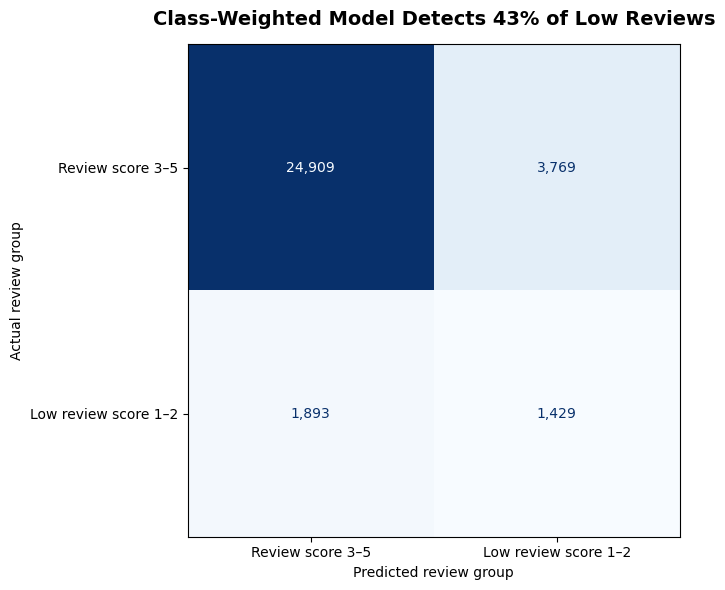

In [9]:
default_threshold = 0.50

default_test_predictions = (
    test_probabilities
    >= default_threshold
).astype(int)

test_confusion_matrix = confusion_matrix(
    y_test,
    default_test_predictions
)

true_negatives = test_confusion_matrix[0, 0]
false_positives = test_confusion_matrix[0, 1]
false_negatives = test_confusion_matrix[1, 0]
true_positives = test_confusion_matrix[1, 1]

confusion_summary = pd.DataFrame({
    "outcome": [
        "Correctly identified non-low reviews",
        "Non-low reviews incorrectly flagged",
        "Low reviews missed",
        "Low reviews correctly identified"
    ],
    "orders": [
        true_negatives,
        false_positives,
        false_negatives,
        true_positives
    ]
})

display(
    confusion_summary.style.format({
        "orders": "{:,.0f}"
    })
)

fig, ax = plt.subplots(figsize=(7, 6))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "Review score 3–5",
        "Low review score 1–2"
    ]
)

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format=",d"
)

ax.set_title(
    "Class-Weighted Model Detects 43% of Low Reviews",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Predicted review group")
ax.set_ylabel("Actual review group")

plt.tight_layout()

output_path = (
    IMAGES_DIR
    / "low_review_prediction_confusion_matrix.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** At the predefined 0.50 threshold, the model correctly identifies 1,429 of 3,322 low-review orders but misses 1,893 and incorrectly flags 3,769 non-low-review orders. The model therefore provides moderate prioritization ability rather than dependable order-level classification, with higher recall achieved at the cost of many false alerts.

## 9. Inspect Model Coefficients

Review the largest logistic-regression coefficients to understand which features are most strongly associated with the model’s low-review predictions, without interpreting them as causal effects.

,feature,coefficient,odds_multiplier,association_direction
0,customer_state_AM,-0.644,0.53,Lower predicted low-review likelihood
1,delivery_delay_days,0.557,1.74,Higher predicted low-review likelihood
2,customer_state_AP,-0.553,0.58,Lower predicted low-review likelihood
3,customer_state_RR,-0.515,0.60,Lower predicted low-review likelihood
4,delivery_days,0.502,1.65,Higher predicted low-review likelihood
5,customer_state_RN,-0.493,0.61,Lower predicted low-review likelihood
6,customer_state_SP,0.417,1.52,Higher predicted low-review likelihood
7,customer_state_RJ,0.400,1.49,Higher predicted low-review likelihood
8,customer_state_DF,0.351,1.42,Higher predicted low-review likelihood
9,customer_state_MG,0.296,1.34,Higher predicted low-review likelihood


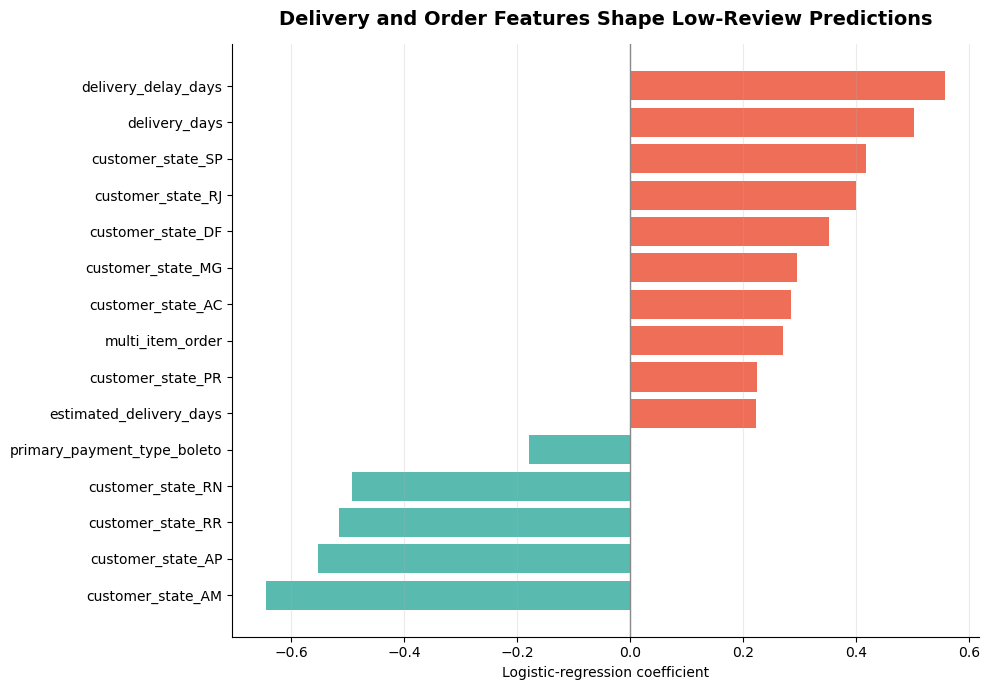

In [10]:
fitted_preprocessor = selected_model.named_steps[
    "preprocessor"
]

fitted_classifier = selected_model.named_steps[
    "classifier"
]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

model_coefficients = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient":
        fitted_classifier.coef_[0]
})

model_coefficients["feature"] = (
    model_coefficients["feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

model_coefficients["absolute_coefficient"] = (
    model_coefficients[
        "coefficient"
    ].abs()
)

model_coefficients["association_direction"] = np.where(
    model_coefficients["coefficient"] > 0,
    "Higher predicted low-review likelihood",
    "Lower predicted low-review likelihood"
)

model_coefficients["odds_multiplier"] = np.exp(
    model_coefficients["coefficient"]
)

top_model_coefficients = (
    model_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(
    top_model_coefficients[
        [
            "feature",
            "coefficient",
            "odds_multiplier",
            "association_direction"
        ]
    ].style.format({
        "coefficient": "{:.3f}",
        "odds_multiplier": "{:.2f}"
    })
)

fig, ax = plt.subplots(figsize=(10, 7))

coefficient_plot = (
    top_model_coefficients
    .sort_values("coefficient")
)

bar_colors = np.where(
    coefficient_plot["coefficient"] > 0,
    COLORS["negative"],
    COLORS["positive"]
)

ax.barh(
    coefficient_plot["feature"],
    coefficient_plot["coefficient"],
    color=bar_colors,
    alpha=0.85
)

ax.axvline(
    0,
    color=COLORS["neutral"],
    linewidth=1
)

ax.set_title(
    "Delivery and Order Features Shape Low-Review Predictions",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Logistic-regression coefficient")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = (
    IMAGES_DIR
    / "low_review_prediction_coefficients.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Longer delivery time and greater delivery delay are among the strongest positive contributors to low-review predictions, while multi-item orders also increase the model score. State coefficients should be interpreted cautiously because some states have relatively few orders and the coefficients may reflect differences in sample composition; these are predictive associations, not evidence that location causes low satisfaction.

## 10. Visualize Precision–Recall Performance

Compare both logistic models across all decision thresholds, focusing on their ability to identify the minority low-review class relative to the no-skill prevalence benchmark.

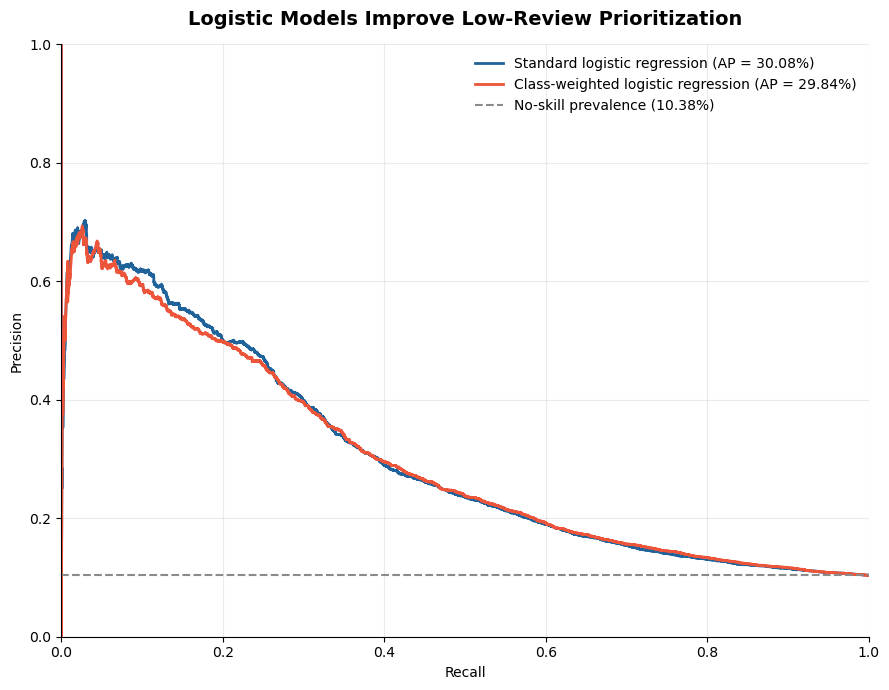

Standard logistic-regression PR-AUC: 30.08%
Class-weighted logistic-regression PR-AUC: 29.84%
No-skill PR-AUC benchmark: 10.38%


In [11]:
standard_test_probabilities = (
    trained_models[
        "Logistic regression"
    ]
    .predict_proba(X_test)[:, 1]
)

weighted_test_probabilities = (
    trained_models[
        "Class-weighted logistic regression"
    ]
    .predict_proba(X_test)[:, 1]
)

standard_precision, standard_recall, _ = (
    precision_recall_curve(
        y_test,
        standard_test_probabilities
    )
)

weighted_precision, weighted_recall, _ = (
    precision_recall_curve(
        y_test,
        weighted_test_probabilities
    )
)

standard_pr_auc = average_precision_score(
    y_test,
    standard_test_probabilities
)

weighted_pr_auc = average_precision_score(
    y_test,
    weighted_test_probabilities
)

no_skill_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    standard_recall,
    standard_precision,
    linewidth=2,
    color=COLORS["secondary"],
    label=(
        "Standard logistic regression "
        f"(AP = {standard_pr_auc:.2%})"
    )
)

ax.plot(
    weighted_recall,
    weighted_precision,
    linewidth=2,
    color=COLORS["negative"],
    label=(
        "Class-weighted logistic regression "
        f"(AP = {weighted_pr_auc:.2%})"
    )
)

ax.axhline(
    no_skill_rate,
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "No-skill prevalence "
        f"({no_skill_rate:.2%})"
    )
)

ax.set_title(
    "Logistic Models Improve Low-Review Prioritization",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

output_path = (
    IMAGES_DIR
    / "low_review_precision_recall_curve.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Standard logistic-regression PR-AUC:",
    f"{standard_pr_auc:.2%}"
)

print(
    "Class-weighted logistic-regression PR-AUC:",
    f"{weighted_pr_auc:.2%}"
)

print(
    "No-skill PR-AUC benchmark:",
    f"{no_skill_rate:.2%}"
)

***Observation:*** Both logistic models provide substantially better ranking performance than the 10.38% no-skill benchmark, reaching PR-AUC values near 30%. The standard model ranks orders slightly better overall, while class weighting mainly changes the classification trade-off at the 0.50 threshold rather than improving probability ranking.

## 11. Assess Monthly Test-Period Stability

Measure the class-weighted model’s performance separately for each test month to determine whether its precision and recall remain stable over time.

In [12]:
monthly_test_results = pd.DataFrame({
    "purchase_month_start": (
        modeling_orders.loc[
            test_mask,
            "order_purchase_timestamp"
        ]
        .dt.to_period("M")
        .dt.to_timestamp()
        .to_numpy()
    ),
    "actual_low_review":
        y_test.to_numpy(),
    "predicted_low_review":
        default_test_predictions,
    "predicted_probability":
        weighted_test_probabilities
})

monthly_metric_records = []

for purchase_month, month_data in (
    monthly_test_results.groupby(
        "purchase_month_start"
    )
):
    monthly_metric_records.append({
        "purchase_month_start":
            purchase_month,
        "orders":
            len(month_data),
        "actual_low_reviews":
            month_data[
                "actual_low_review"
            ].sum(),
        "actual_low_review_rate":
            month_data[
                "actual_low_review"
            ].mean(),
        "predicted_low_reviews":
            month_data[
                "predicted_low_review"
            ].sum(),
        "precision":
            precision_score(
                month_data[
                    "actual_low_review"
                ],
                month_data[
                    "predicted_low_review"
                ],
                zero_division=0
            ),
        "recall":
            recall_score(
                month_data[
                    "actual_low_review"
                ],
                month_data[
                    "predicted_low_review"
                ],
                zero_division=0
            ),
        "f1_score":
            f1_score(
                month_data[
                    "actual_low_review"
                ],
                month_data[
                    "predicted_low_review"
                ],
                zero_division=0
            ),
        "pr_auc":
            average_precision_score(
                month_data[
                    "actual_low_review"
                ],
                month_data[
                    "predicted_probability"
                ]
            ),
        "roc_auc":
            roc_auc_score(
                month_data[
                    "actual_low_review"
                ],
                month_data[
                    "predicted_probability"
                ]
            )
    })

monthly_test_metrics = pd.DataFrame(
    monthly_metric_records
)

display(
    monthly_test_metrics.style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "orders": "{:,.0f}",
        "actual_low_reviews": "{:,.0f}",
        "actual_low_review_rate": "{:.2%}",
        "predicted_low_reviews": "{:,.0f}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1_score": "{:.2%}",
        "pr_auc": "{:.2%}",
        "roc_auc": "{:.2%}"
    })
)

,purchase_month_start,orders,actual_low_reviews,actual_low_review_rate,predicted_low_reviews,precision,recall,f1_score,pr_auc,roc_auc
0,2018-04,"6,752",796,11.79%,"1,407",29.85%,52.76%,38.13%,38.19%,73.10%
1,2018-05,"6,722",723,10.76%,"1,648",23.97%,54.63%,33.32%,31.02%,72.39%
2,2018-06,"6,075",607,9.99%,668,28.74%,31.63%,30.12%,25.33%,67.93%
3,2018-07,"6,121",592,9.67%,798,25.44%,34.29%,29.21%,24.19%,65.79%
4,2018-08,"6,330",604,9.54%,677,32.35%,36.26%,34.19%,29.43%,71.27%


***Observation:*** Model performance varies meaningfully across the five test months: recall ranges from 31.63% to 54.63%, while PR-AUC ranges from 24.19% to 38.19%. The decline after May demonstrates temporal instability and reinforces that the model would require ongoing monitoring and recalibration before any practical use.

## 12. Measure the Contribution of Completed-Delivery Features

Compare the full post-delivery model with a version that excludes actual delivery duration, delivery delay, and delivery-metric availability to show how the defined prediction point affects performance.

In [13]:
completed_delivery_features = [
    "delivery_days",
    "delivery_delay_days",
    "delivery_metric_available"
]

pre_delivery_numeric_features = [
    feature
    for feature in numeric_features
    if feature not in completed_delivery_features
]

pre_delivery_features = (
    pre_delivery_numeric_features
    + categorical_features
)

pre_delivery_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            clone(numeric_transformer),
            pre_delivery_numeric_features
        ),
        (
            "categorical",
            clone(categorical_transformer),
            categorical_features
        )
    ]
)

pre_delivery_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            pre_delivery_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2_000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

pre_delivery_pipeline.fit(
    X_train[pre_delivery_features],
    y_train
)

pre_delivery_probabilities = (
    pre_delivery_pipeline.predict_proba(
        X_test[pre_delivery_features]
    )[:, 1]
)

pre_delivery_predictions = (
    pre_delivery_probabilities >= 0.50
).astype(int)

feature_set_comparison = pd.DataFrame([
    {
        "feature_set":
            "Before completed-delivery metrics",
        "features":
            len(pre_delivery_features),
        "precision":
            precision_score(
                y_test,
                pre_delivery_predictions,
                zero_division=0
            ),
        "recall":
            recall_score(
                y_test,
                pre_delivery_predictions,
                zero_division=0
            ),
        "f1_score":
            f1_score(
                y_test,
                pre_delivery_predictions,
                zero_division=0
            ),
        "pr_auc":
            average_precision_score(
                y_test,
                pre_delivery_probabilities
            ),
        "roc_auc":
            roc_auc_score(
                y_test,
                pre_delivery_probabilities
            )
    },
    {
        "feature_set":
            "After completed-delivery metrics",
        "features":
            len(model_features),
        "precision":
            precision_score(
                y_test,
                default_test_predictions,
                zero_division=0
            ),
        "recall":
            recall_score(
                y_test,
                default_test_predictions,
                zero_division=0
            ),
        "f1_score":
            f1_score(
                y_test,
                default_test_predictions,
                zero_division=0
            ),
        "pr_auc":
            average_precision_score(
                y_test,
                weighted_test_probabilities
            ),
        "roc_auc":
            roc_auc_score(
                y_test,
                weighted_test_probabilities
            )
    }
])

display(
    feature_set_comparison.style.format({
        "features": "{:,.0f}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1_score": "{:.2%}",
        "pr_auc": "{:.2%}",
        "roc_auc": "{:.2%}"
    })
)

,feature_set,features,precision,recall,f1_score,pr_auc,roc_auc
0,Before completed-delivery metrics,18,15.19%,44.73%,22.68%,19.33%,60.20%
1,After completed-delivery metrics,21,27.49%,43.02%,33.54%,29.84%,70.09%


***Observation:*** Adding completed-delivery metrics raises PR-AUC from 19.33% to 29.84% and F1 from 22.68% to 33.54%, while recall remains similar. Actual delivery performance therefore provides substantial predictive information, but it also limits the model’s use to intervention after delivery and before review submission.

## 13. Validate the Classification Workflow

Confirm population coverage, target integrity, leakage prevention, chronological separation, prediction completeness, and consistency across evaluation tables.

In [15]:
invalid_test_probabilities = (
    pd.Series(
        weighted_test_probabilities
    )
    .lt(0)
    .sum()
    +
    pd.Series(
        weighted_test_probabilities
    )
    .gt(1)
    .sum()
    +
    pd.Series(
        weighted_test_probabilities
    )
    .isna()
    .sum()
)

prediction_validation = pd.DataFrame({
    "validation_check": [
        "Reviewed delivered orders represented",
        "Duplicate modeling order IDs",
        "Invalid target labels",
        "Review-derived predictors included",
        "Training and test rows represented",
        "Chronological train-test split",
        "Test predictions represented",
        "Invalid test probabilities",
        "Confusion-matrix orders represented",
        "Monthly test orders represented",
        "Validation threshold within valid range",
        "Feature-set comparisons represented"
    ],
    "result": [
        len(modeling_orders),
        modeling_orders[
            "order_id"
        ].duplicated().sum(),
        (~modeling_orders[
            "low_review_flag"
        ].isin([0, 1])).sum(),
        len(review_derived_predictors),
        len(X_train) + len(X_test),
        chronological_split_valid,
        len(default_test_predictions),
        invalid_test_probabilities,
        test_confusion_matrix.sum(),
        monthly_test_metrics[
            "orders"
        ].sum(),
        int(
            0 <= selected_threshold <= 1
        ),
        len(feature_set_comparison)
    ],
    "expected": [
        95_832,
        0,
        0,
        0,
        len(modeling_orders),
        1,
        len(X_test),
        0,
        len(X_test),
        len(X_test),
        1,
        2
    ]
})

prediction_validation["status"] = np.where(
    prediction_validation["result"]
    == prediction_validation["expected"],
    "Passed",
    "Failed"
)

display(
    prediction_validation.style.format({
        "result": "{:,.0f}",
        "expected": "{:,.0f}"
    })
)

,validation_check,result,expected,status
0,Reviewed delivered orders represented,"95,832","95,832",Passed
1,Duplicate modeling order IDs,0,0,Passed
2,Invalid target labels,0,0,Passed
3,Review-derived predictors included,0,0,Passed
4,Training and test rows represented,"95,832","95,832",Passed
5,Chronological train-test split,1,1,Passed
6,Test predictions represented,"32,000","32,000",Passed
7,Invalid test probabilities,0,0,Passed
8,Confusion-matrix orders represented,"32,000","32,000",Passed
9,Monthly test orders represented,"32,000","32,000",Passed


***Observation:*** All validation checks passed. The workflow represents all 95,832 eligible orders, contains no duplicate records or invalid targets, excludes review-derived predictors, preserves the chronological split, and produces complete valid predictions for all 32,000 test orders.

## 14. Export Prediction Results

Export the modeling table, evaluation results, test predictions, coefficient summary, stability analysis, feature-set comparison, and final validation report.

In [16]:
prediction_modeling_table = modeling_orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "latest_review_score",
        "low_review_flag"
    ]
    + model_features
].copy()

threshold_validation_results = pd.DataFrame({
    "decision_threshold":
        validation_thresholds,
    "precision":
        validation_precision[:-1],
    "recall":
        validation_recall[:-1],
    "f1_score":
        threshold_f1_scores
})

test_prediction_export = pd.DataFrame({
    "order_id": modeling_orders.loc[
        test_mask,
        "order_id"
    ].to_numpy(),

    "order_purchase_timestamp":
        modeling_orders.loc[
            test_mask,
            "order_purchase_timestamp"
        ].to_numpy(),

    "actual_low_review":
        y_test.to_numpy(),

    "standard_logistic_probability":
        standard_test_probabilities,

    "weighted_logistic_probability":
        weighted_test_probabilities,

    "weighted_prediction_threshold_050":
        default_test_predictions,

    "validation_selected_threshold":
        selected_threshold,

    "weighted_prediction_selected_threshold":
        threshold_test_predictions
})

prediction_export_files = {
    "low_review_modeling_table.csv":
        prediction_modeling_table,

    "low_review_feature_audit.csv":
        feature_audit,

    "low_review_split_summary.csv":
        split_summary,

    "low_review_model_comparison.csv":
        model_comparison,

    "low_review_threshold_validation.csv":
        threshold_validation_results,

    "low_review_threshold_test_results.csv":
        threshold_test_results,

    "low_review_test_predictions.csv":
        test_prediction_export,

    "low_review_model_coefficients.csv":
        model_coefficients,

    "low_review_monthly_test_metrics.csv":
        monthly_test_metrics,

    "low_review_feature_set_comparison.csv":
        feature_set_comparison,

    "low_review_prediction_validation.csv":
        prediction_validation
}

for filename, dataframe in (
    prediction_export_files.items()
):
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_prediction_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in prediction_export_files
)

print(
    "Prediction files exported:",
    len(prediction_export_files)
)

print(
    "All prediction files created:",
    all_prediction_files_created
)

Prediction files exported: 11
All prediction files created: True


***Observation:*** All 11 prediction files were exported successfully. The outputs preserve the complete classification workflow, including feature documentation, chronological evaluation, threshold testing, order-level predictions, model coefficients, temporal stability results, and final validation.

## 15. Conclusion

***Conclusion:*** This notebook developed a leakage-aware classification workflow for estimating whether a delivered order would receive a low review score of 1 or 2. The modeling population contained 95,832 reviewed delivered orders, of which 12.81% received a low score, and the model was evaluated on a strictly later test period containing 32,000 orders.

At the predefined 0.50 threshold, class-weighted logistic regression achieved 43.02% recall, 27.49% precision, a 33.54% F1 score, and 64.94% balanced accuracy. It correctly identified 1,429 of the 3,322 low-review orders in the test period while incorrectly flagging 3,769 non-low-review orders. Both logistic models achieved PR-AUC values near 30%, substantially exceeding the 10.38% no-skill benchmark.

Completed-delivery information contributed materially to prediction quality. Including actual delivery duration and delay increased PR-AUC from 19.33% to 29.84% and F1 from 22.68% to 33.54%. Consequently, the stronger model is appropriate only for scoring after delivery but before review submission; it is not an order-time prediction model.

The validation-selected threshold did not remain stable on the later test period, and monthly performance also varied meaningfully. These results demonstrate classification, imbalance handling, chronological validation, threshold analysis, model interpretation, and temporal monitoring, but the model should be considered a prioritization experiment rather than a dependable automated decision system.